# My first model

## Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

I0000 00:00:1785952270.823228   58430 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785952270.899300   58430 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%matplotlib widget
plt.close('all')

## Load Data

In [3]:
from pathlib import Path

data_path = Path("data.dat")
if not data_path.exists():
    data_path = Path("FirstSteps/data.dat")

x_tr, y_tr, x_val, y_val = np.loadtxt(data_path, unpack=True)

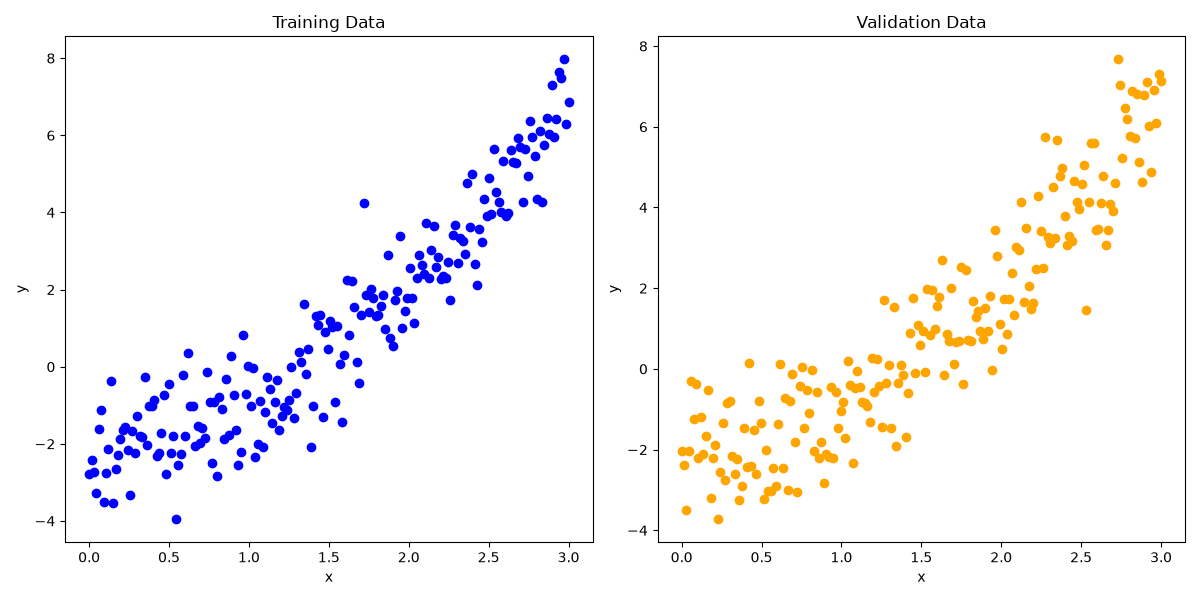

In [4]:
# plot data for training and validation
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.scatter(x_tr, y_tr, label='Training Data', color='blue')
plt.title('Training Data')
plt.xlabel('x')
plt.ylabel('y')
plt.subplot(1, 2, 2)
plt.scatter(x_val, y_val, label='Validation Data', color='orange')
plt.title('Validation Data')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

## Model Definition

In [5]:
class LinearModel(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        
        self.m = tf.Variable(np.random.randn(), name='m')
        self.q = tf.Variable(np.random.randn(), name='q')

    def __call__(self, x):
        return self.m * x + self.q
    
    def loss(self, y_pred, y_true):
        return tf.reduce_mean(tf.square(y_pred - y_true))
    
    def train_step(self, x, y, learning_rate=0.01):
        with tf.GradientTape() as tape:
            y_pred = self(x)
            current_loss = self.loss(y_pred, y)
            
        gradients = tape.gradient(current_loss, [self.m, self.q])
        self.m.assign_sub(learning_rate * gradients[0])
        self.q.assign_sub(learning_rate * gradients[1])
        return current_loss
    
    def train_loop(self, x, y, epochs=1000, learning_rate=0.01):
        m_values = []
        q_values = []
        loss_values = []
        
        for epoch in range(epochs):
            current_loss = self.train_step(x, y, learning_rate)
            
            if epoch % 10 == 0:
                print(f'Epoch {epoch}: Loss: {current_loss.numpy()}')
                
            m_values.append(self.m.numpy())
            q_values.append(self.q.numpy())
            loss_values.append(current_loss.numpy())
    
        return m_values, q_values, loss_values
    

In [11]:
class Dense(tf.Module):
    def __init__(self, input_dim, output_dim, activation=tf.nn.relu, name=None):
        super().__init__(name=name)
        self.W = tf.Variable(tf.random.normal([input_dim, output_dim]), name='W')
        self.b = tf.Variable(tf.zeros([output_dim]), name='b')
        self.activation = activation

    def __call__(self, x):
        z = tf.matmul(x, self.W) + self.b
        return self.activation(z)


class NonLinearModel(tf.Module):
    def __init__(self, hidden_units=16, name=None):
        super().__init__(name=name)
        self.hidden = Dense(1, hidden_units, activation=tf.nn.relu)
        self.out = Dense(hidden_units, 1, activation=lambda z: z)

    def __call__(self, x):
        # x deve gia' essere un tensore float32 di shape (N, 1):
        # la conversione avviene in train_loop() e in predict().
        return self.out(self.hidden(x))

    def loss(self, y_true, y_pred):
        return tf.reduce_mean(tf.square(y_true - y_pred))

    def predict(self, x):
        """Accetta array numpy di shape (N,) o (N,1) e restituisce (N,)."""
        x = tf.reshape(tf.convert_to_tensor(x, dtype=tf.float32), (-1, 1))
        return self(x).numpy().ravel()

    def train_step(self, x, y, learning_rate=0.01):
        with tf.GradientTape() as tape:
            current_loss = self.loss(y, self(x))
        variables = self.trainable_variables
        gradients = tape.gradient(current_loss, variables)
        for v, g in zip(variables, gradients):
            v.assign_sub(learning_rate * g)
        return current_loss

    def train_loop(self, x, y, epochs=1000, learning_rate=0.01):
        x = tf.reshape(tf.convert_to_tensor(x, dtype=tf.float32), (-1, 1))
        y = tf.reshape(tf.convert_to_tensor(y, dtype=tf.float32), (-1, 1))

        loss_values = []
        for epoch in range(epochs):
            current_loss = self.train_step(x, y, learning_rate)
            if epoch % 10 == 0:
                print(f'Epoch {epoch}: Loss: {current_loss.numpy():.6f}')
            loss_values.append(float(current_loss.numpy()))
        return loss_values

## Training

In [7]:
my_model = LinearModel()

m_values, q_values, loss_values = my_model.train_loop(x_tr, y_tr, epochs=500, learning_rate=1e-2)

Epoch 0: Loss: 11.107708930969238
Epoch 10: Loss: 5.3234171867370605
Epoch 20: Loss: 3.9732134342193604
Epoch 30: Loss: 3.544712543487549
Epoch 40: Loss: 3.3168084621429443
Epoch 50: Loss: 3.140763521194458
Epoch 60: Loss: 2.985260009765625
Epoch 70: Loss: 2.8431177139282227
Epoch 80: Loss: 2.7121634483337402
Epoch 90: Loss: 2.591304302215576
Epoch 100: Loss: 2.4797182083129883
Epoch 110: Loss: 2.37668514251709
Epoch 120: Loss: 2.2815473079681396
Epoch 130: Loss: 2.193699598312378
Epoch 140: Loss: 2.1125829219818115
Epoch 150: Loss: 2.037681818008423
Epoch 160: Loss: 1.968519687652588
Epoch 170: Loss: 1.904657006263733
Epoch 180: Loss: 1.8456882238388062
Epoch 190: Loss: 1.791237473487854
Epoch 200: Loss: 1.7409590482711792
Epoch 210: Loss: 1.694533109664917
Epoch 220: Loss: 1.65166437625885
Epoch 230: Loss: 1.6120803356170654
Epoch 240: Loss: 1.5755294561386108
Epoch 250: Loss: 1.5417795181274414
Epoch 260: Loss: 1.5106152296066284
Epoch 270: Loss: 1.4818392992019653
Epoch 280: Loss: 

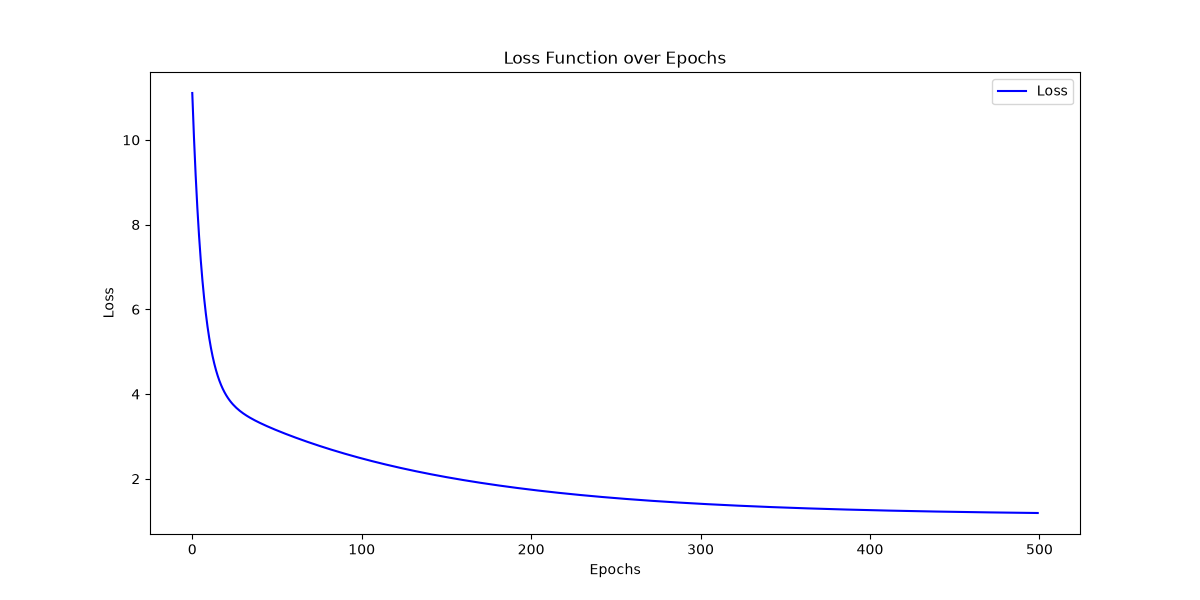

In [8]:
#plot della loss function
plt.figure(figsize=(12,6))
plt.plot(loss_values, label='Loss', color='blue')
plt.title('Loss Function over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

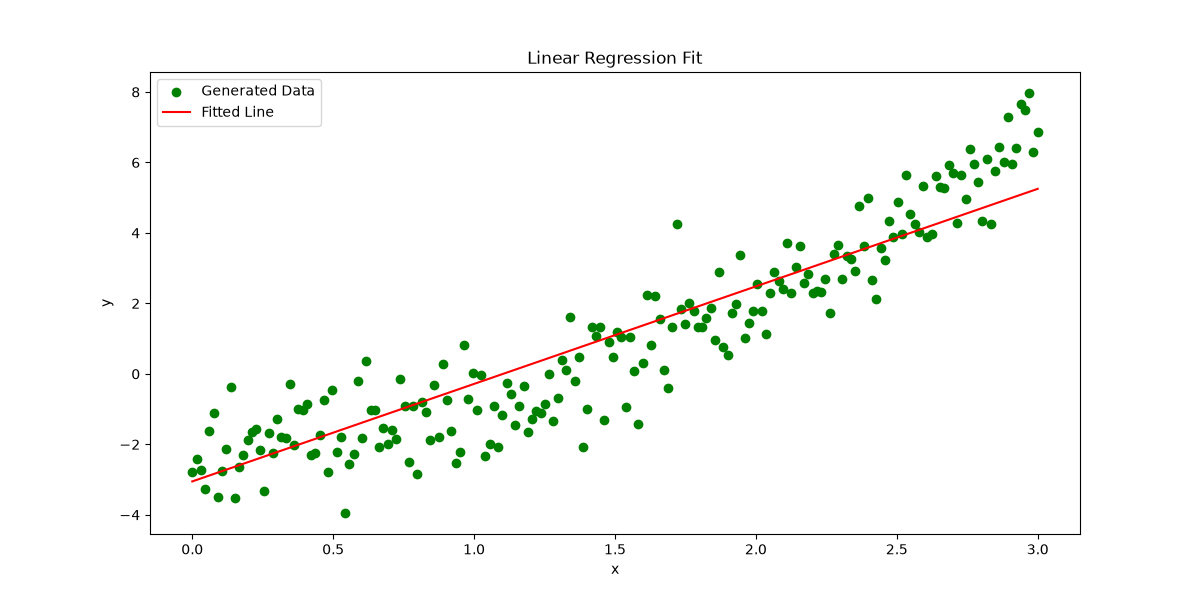

In [9]:
# Plotting the results
plt.figure(figsize=(12,6))
plt.scatter(x_tr, y_tr, color='green', marker='o', label='Generated Data')
plt.plot(x_tr, my_model(x_tr), color='red', label='Fitted Line')
plt.title('Linear Regression Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [12]:
second_model = NonLinearModel()

loss_values_nl = second_model.train_loop(x_tr.reshape(-1, 1), y_tr.reshape(-1, 1), epochs=500, learning_rate=1e-2)

Epoch 0: Loss: 28.414431
Epoch 10: Loss: 2.523602
Epoch 20: Loss: 1.549446
Epoch 30: Loss: 1.223414
Epoch 40: Loss: 1.113164
Epoch 50: Loss: 1.074688
Epoch 60: Loss: 1.059884
Epoch 70: Loss: 1.053089
Epoch 80: Loss: 1.049047
Epoch 90: Loss: 1.045894
Epoch 100: Loss: 1.041500
Epoch 110: Loss: 1.037299
Epoch 120: Loss: 1.032702
Epoch 130: Loss: 1.027384
Epoch 140: Loss: 1.021023
Epoch 150: Loss: 1.013984
Epoch 160: Loss: 1.007378
Epoch 170: Loss: 1.000943
Epoch 180: Loss: 0.993905
Epoch 190: Loss: 0.986792
Epoch 200: Loss: 0.979182
Epoch 210: Loss: 0.971478
Epoch 220: Loss: 0.964208
Epoch 230: Loss: 0.959286
Epoch 240: Loss: 0.955175
Epoch 250: Loss: 0.951559
Epoch 260: Loss: 0.947013
Epoch 270: Loss: 0.942201
Epoch 280: Loss: 0.935941
Epoch 290: Loss: 0.928470
Epoch 300: Loss: 0.920319
Epoch 310: Loss: 0.912851
Epoch 320: Loss: 0.905987
Epoch 330: Loss: 0.899527
Epoch 340: Loss: 0.893242
Epoch 350: Loss: 0.885563
Epoch 360: Loss: 0.878951
Epoch 370: Loss: 0.872624
Epoch 380: Loss: 0.867

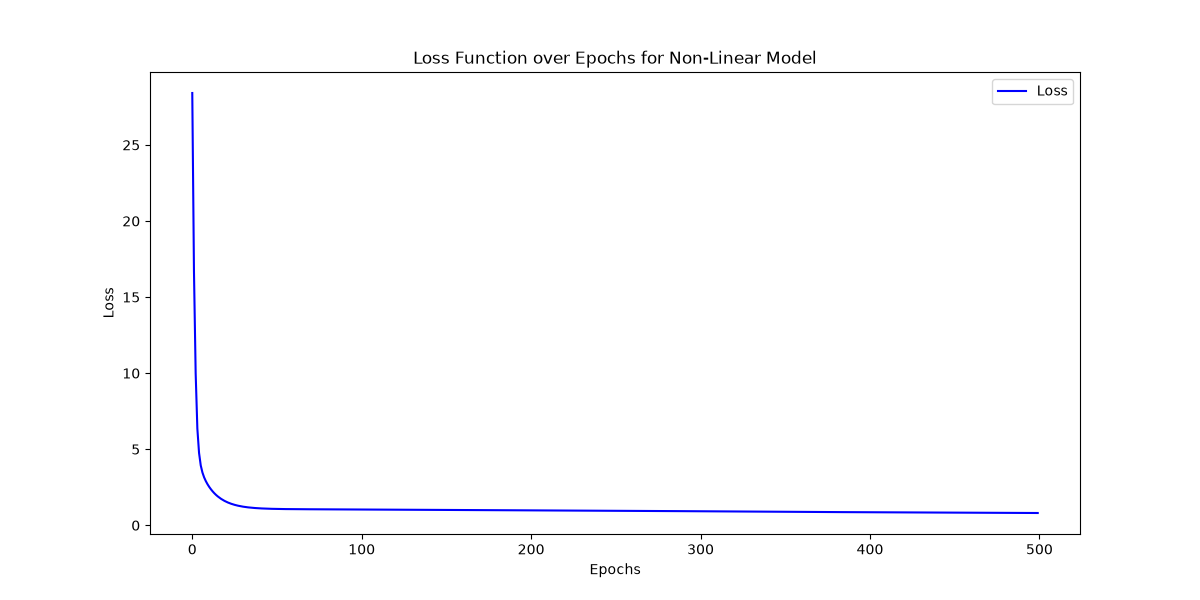

In [13]:
# loss function plot for the non-linear model
plt.figure(figsize=(12,6))
plt.plot(loss_values_nl, label='Loss', color='blue')
plt.title('Loss Function over Epochs for Non-Linear Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

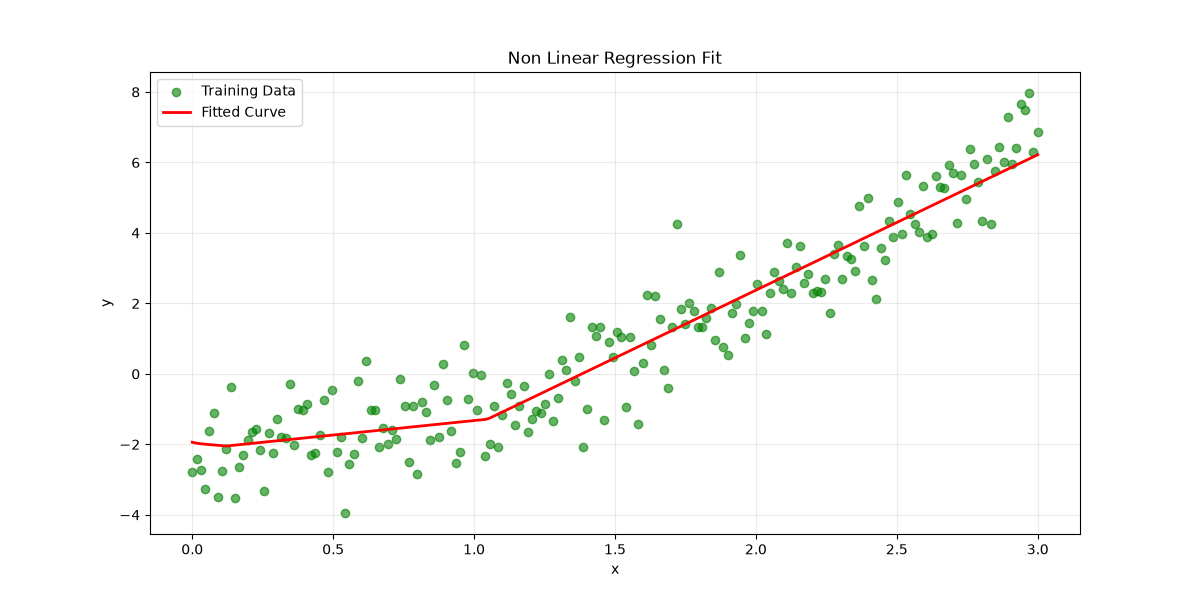

In [ ]:
# Plotting the results
plt.figure(figsize=(12,6))
plt.scatter(x_tr, y_tr, color='green', marker='o', alpha=0.6, label='Training Data')

x_line = np.linspace(x_tr.min(), x_tr.max(), 200)
plt.plot(x_line, second_model.predict(x_line), color='red', linewidth=2, label='Fitted Curve')

plt.title('Non Linear Regression Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.25)
plt.show()